In [1]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import random

plt.style.use('ggplot')

### Cek Distribusi Kelas (Jumlah Gambar per Kategori)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_2184\3553488610.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(class_counts.values()), y=list(class_counts.keys()), palette='viridis')


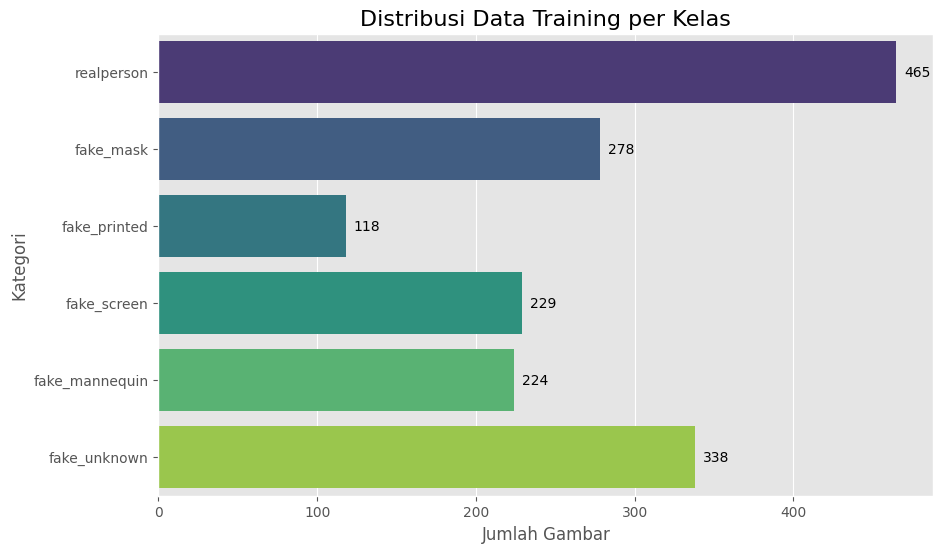

In [2]:
dataset_path = '../Data/train/' 

classes = ['realperson', 'fake_mask', 'fake_printed', 'fake_screen', 'fake_mannequin', 'fake_unknown']
class_counts = {}

for cls in classes:
    class_path = os.path.join(dataset_path, cls)
    if os.path.exists(class_path):
        num_images = len(os.listdir(class_path))
        class_counts[cls] = num_images
    else:
        class_counts[cls] = 0
        print(f"Folder {cls} tidak ditemukan!")

plt.figure(figsize=(10, 6))
sns.barplot(x=list(class_counts.values()), y=list(class_counts.keys()), palette='viridis')
plt.title('Distribusi Data Training per Kelas', fontsize=16)
plt.xlabel('Jumlah Gambar', fontsize=12)
plt.ylabel('Kategori', fontsize=12)
for i, v in enumerate(class_counts.values()):
    plt.text(v + 5, i, str(v), color='black', va='center')
plt.show()

### Sampel gambar

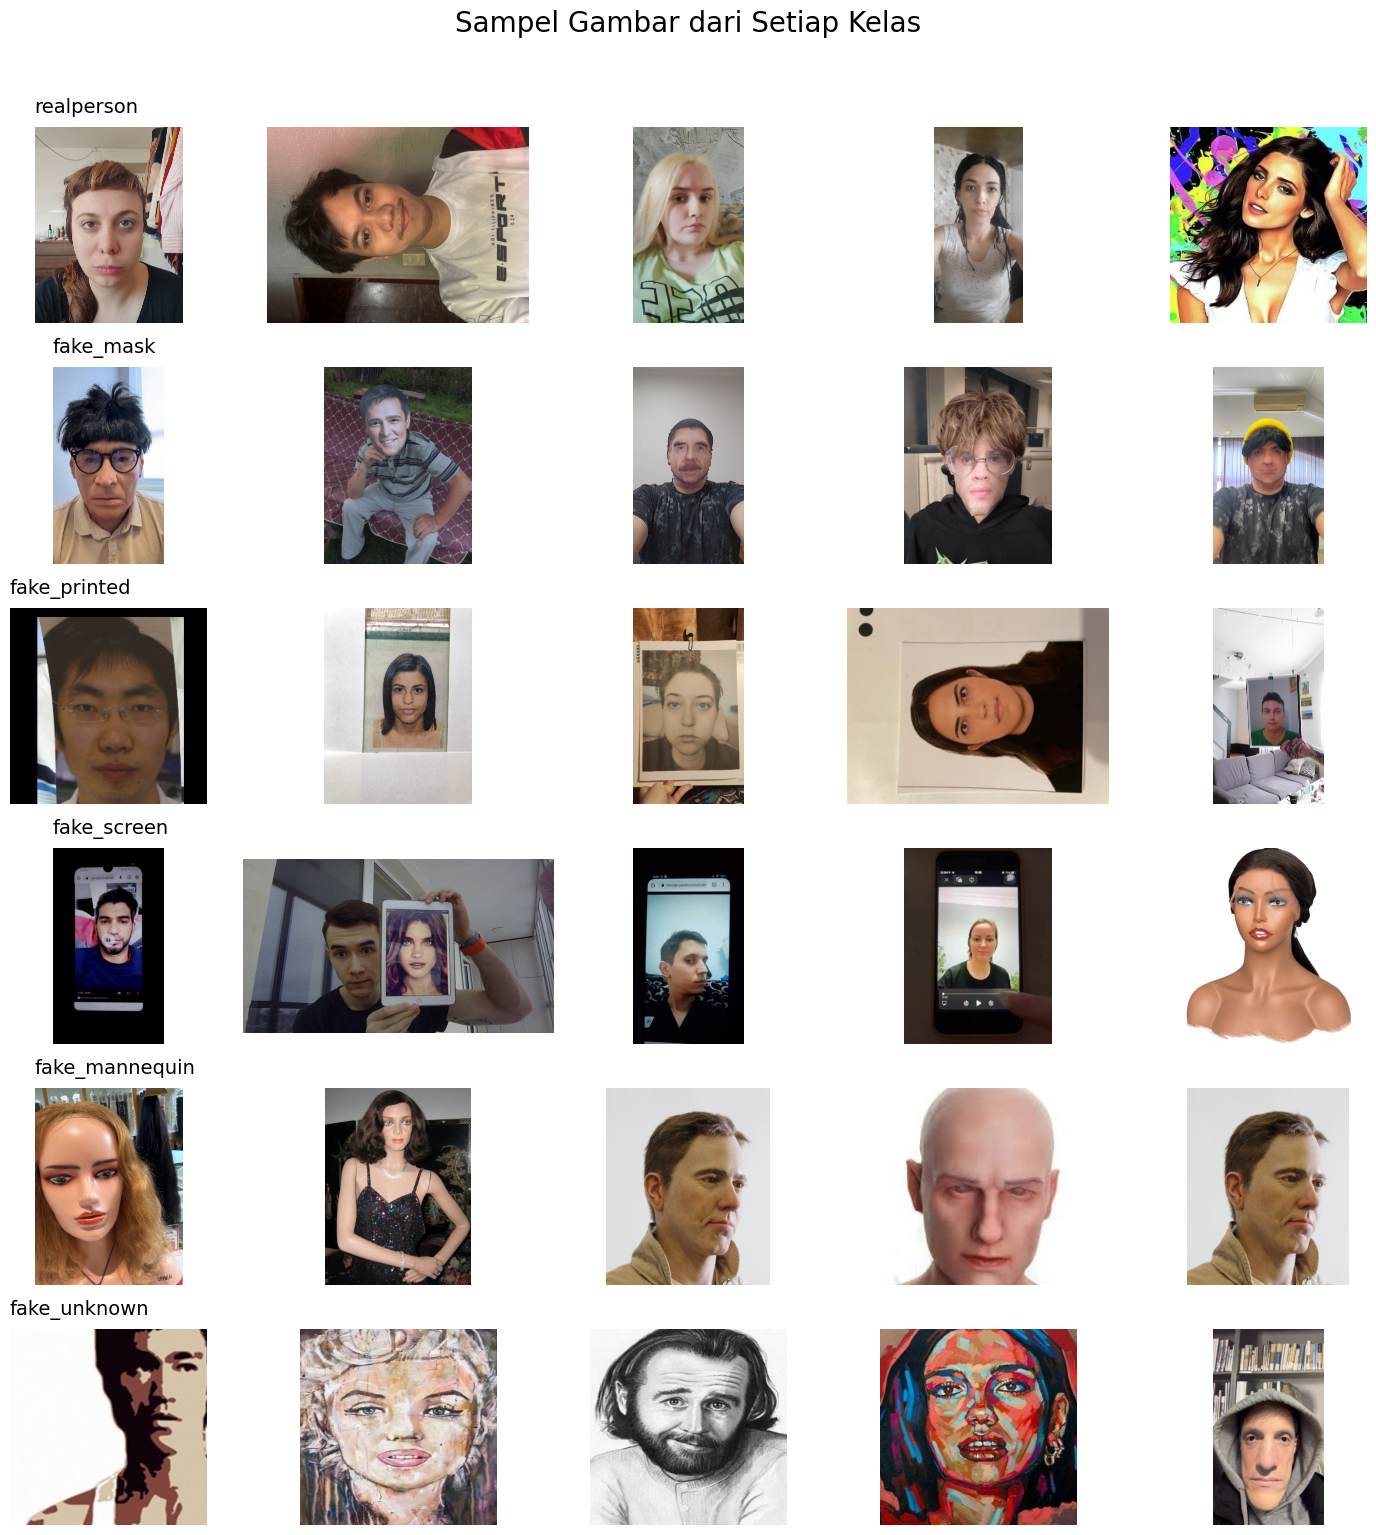

In [3]:
num_samples = 5

fig, axes = plt.subplots(len(classes), num_samples, figsize=(15, 2.5 * len(classes)))
fig.suptitle('Sampel Gambar dari Setiap Kelas', fontsize=20, y=1.02)

for i, cls in enumerate(classes):
    class_path = os.path.join(dataset_path, cls)
    
    if os.path.exists(class_path) and len(os.listdir(class_path)) > 0:
        all_images = os.listdir(class_path)
        sample_images = random.sample(all_images, min(num_samples, len(all_images)))
        
        for j, img_name in enumerate(sample_images):
            img_path = os.path.join(class_path, img_name)
            img = Image.open(img_path)
            
            axes[i, j].imshow(img)
            axes[i, j].axis('off')
            if j == 0:
                axes[i, j].set_title(cls, fontsize=14, loc='left', pad=10)

plt.tight_layout()
plt.show()